# Plot images as points

/Users/mariano/miniconda3/envs/pol-pub/lib/python3.11/site-packages/pandas/core/frame.py:5239: FutureWarning: You are adding a column named 'geometry' to a GeoDataFrame constructed without an active geometry column. Currently, this automatically sets the active geometry column to 'geometry' but in the future that will no longer happen. Instead, either provide geometry to the GeoDataFrame constructor (GeoDataFrame(... geometry=GeoSeries()) or use `set_geometry('geometry')` to explicitly set the active geometry column.
  data[k] = com.apply_if_callable(v, data)


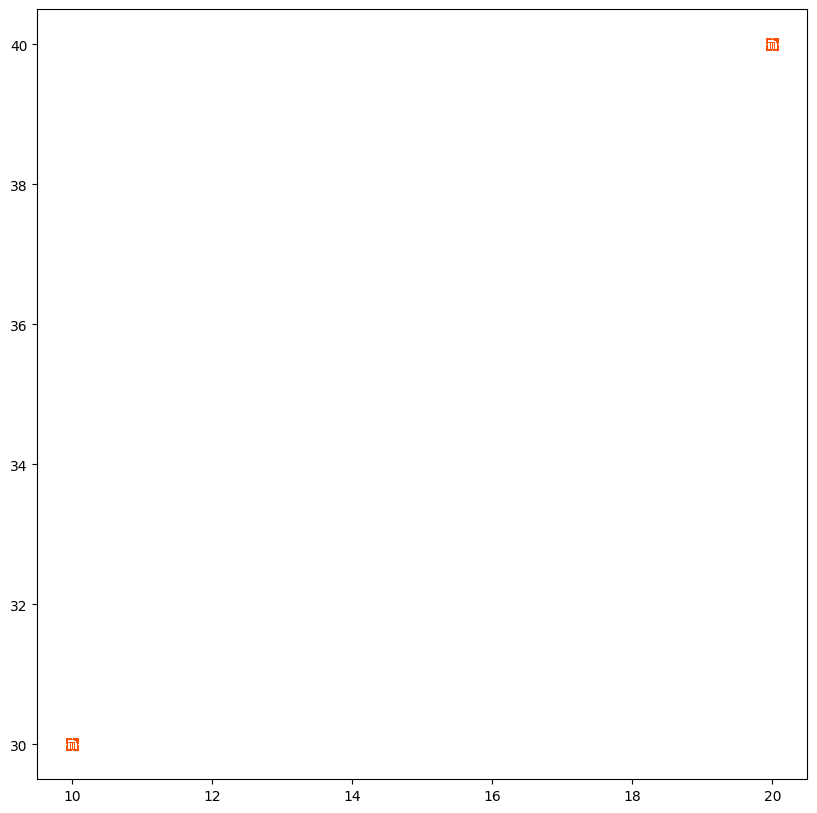

In [2]:
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.offsetbox import OffsetImage, AnnotationBbox

# Sample data
df = (
    gpd
    .GeoDataFrame({
        'location': ['Point 1', 'Point 2'],
        'x': [10, 20],
        'y': [30, 40],
        'image_path': ["../../data/graphs/metro.png", "../../data/graphs/metro.png"]
    })
    .assign(
        geometry=lambda df_: gpd.points_from_xy(df_['x'], df_['y'])
    )
)



# Function to plot images
def plot_images(x, y, image_path, ax):
    for xi, yi, path in zip(x, y, image_path):
        image = plt.imread(path)
        im = OffsetImage(image, zoom=0.007)  # Adjust zoom as needed
        ab = AnnotationBbox(im, (xi, yi), frameon=False, pad=0.0)
        ax.add_artist(ab)

# Plot the map
fig, ax = plt.subplots(figsize=(10, 10))
df.plot(ax=ax, color='lightgrey', edgecolor='black')  # Optional: plot background

# Plot images at each point
plot_images(df['x'], df['y'], df['image_path'], ax)
plt.show()